GitHub Reference
https://github.com/nflverse/nflreadpy


# Data & Installs

In [1]:
# install nfl_verse package
!pip install nflreadpy

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
import pandas as pd
import nflreadpy as nfl
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
import matplotlib.ticker as mtick



# Preprocessing & recent_pbp

In [3]:
# load complete historical play by play dataset natively in polars
pbp = nfl.load_pbp(seasons=True)

# load only seasons 2021-2026 if you meet RAM restrictions
# pbp = nfl.load_pbp(seasons=range(2021, 2026))

# apply global filters for competitive offensive execution to the entire dataset
pbp = pbp.filter(
    pl.col('season_type') == 'REG',
    pl.col('play_type').is_in(['pass', 'run']),
    pl.col('down').is_not_null(),
    pl.col('epa').is_not_null(),
    pl.col('ydstogo') > 0.0,
    pl.col('yards_gained').is_not_null(),
    pl.col('penalty').fill_null(0) == 0,
    pl.col('qb_kneel') == 0,
    pl.col('qb_spike') == 0,
    pl.col('two_point_attempt').fill_null(0) == 0,
    pl.col('wp').is_not_null(),
    pl.col('wp') >= 0.10,
    pl.col('wp') <= 0.90,
    pl.col('posteam').is_not_null()
)

# engineer base evaluation features across the entire historical set
pbp = pbp.with_columns([
    (pl.col('yards_gained') / pl.col('ydstogo')).alias('conversion_pct_gained'),
    pl.when(pl.col('epa') > 0).then(1).otherwise(0).alias('is_pos_epa')
])

# create clamped discrete bin feature for aggregation
pbp = pbp.with_columns(
    pl.when(pl.col('conversion_pct_gained') < 0)
    .then(0.0)
    .when(pl.col('conversion_pct_gained') >= 1.0)
    .then(1.0)
    .otherwise((pl.col('conversion_pct_gained') * 10).floor() / 10)
    .round(1)
    .alias('pct_gained_bin')
)

# instantiate targeted timeframes from the master cleaned dataset
target_seasons = [2021, 2022, 2023, 2024, 2025]

recent_pbp = pbp.filter(pl.col('season').is_in(target_seasons))
current_season = pbp.filter(pl.col('season') == 2025)

# print shape diagnostics to confirm successful branching
print("--- Dataset Diagnostics ---")
print(f"Master PBP Plays: {pbp.height}")
print(f"Recent PBP Plays (2021-2025): {recent_pbp.height}")
print(f"Current Season Plays (2025): {current_season.height}")

--- Dataset Diagnostics ---
Master PBP Plays: 127506
Recent PBP Plays (2021-2025): 127506
Current Season Plays (2025): 25042


In [4]:
# output the filtered dimensions
print(f"Filtered Dataset Shape: {recent_pbp.shape}")

# calculate pass versus run ratio
play_type_counts = recent_pbp['play_type'].value_counts()
total_plays = recent_pbp.shape[0]
play_type_ratios = play_type_counts.with_columns(
    (pl.col('count') / total_plays).alias('percentage')
)

print("\nPass vs Run Ratio:")
print(play_type_ratios)

Filtered Dataset Shape: (127506, 375)

Pass vs Run Ratio:
shape: (2, 3)
┌───────────┬───────┬────────────┐
│ play_type ┆ count ┆ percentage │
│ ---       ┆ ---   ┆ ---        │
│ str       ┆ u32   ┆ f64        │
╞═══════════╪═══════╪════════════╡
│ run       ┆ 54217 ┆ 0.425211   │
│ pass      ┆ 73289 ┆ 0.574789   │
└───────────┴───────┴────────────┘


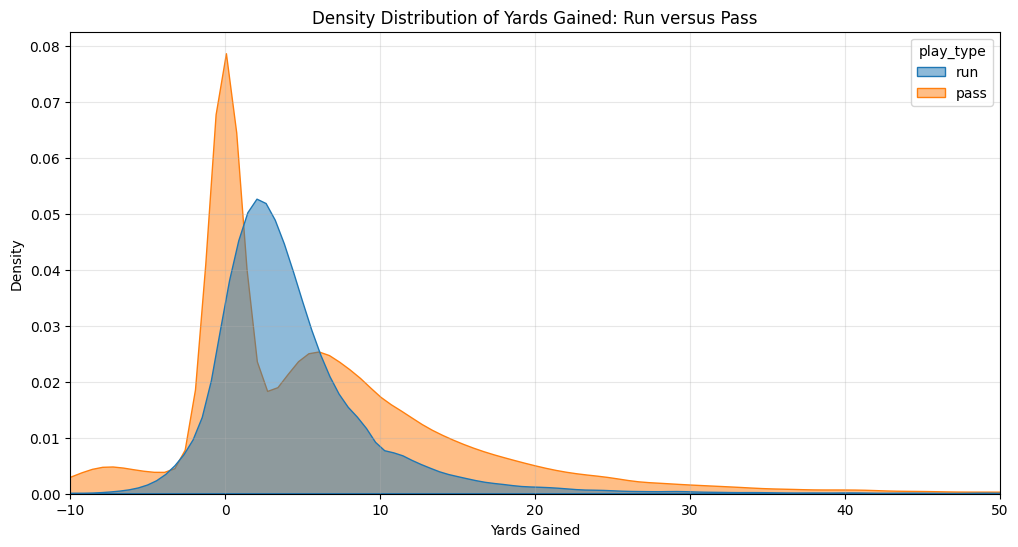

In [5]:
# isolate valid plays and convert to pandas for visualization
plot_df = recent_pbp .filter(pl.col('yards_gained').is_not_null()).to_pandas()

# initialize figure
plt.figure(figsize=(12, 6))

# plot density distribution categorized by play type
sns.kdeplot(data=plot_df, x='yards_gained', hue='play_type', fill=True, alpha=0.5)

# format chart title and axes
plt.title('Density Distribution of Yards Gained: Run versus Pass')
plt.xlabel('Yards Gained')
plt.ylabel('Density')

# restrict horizontal bounds to ignore extreme outliers
plt.xlim(-10, 50)
plt.grid(True, alpha=0.3)
plt.show()

# Feature Creation

--- Traditional Success Preview ---


down,ydstogo,yards_gained,conversion_pct_gained,benchmark_threshold_pct,is_success_benchmark
f64,f64,f64,f64,f64,i32
1.0,10.0,-3.0,-0.3,0.4,0
2.0,13.0,3.0,0.230769,0.6,0
3.0,10.0,0.0,0.0,1.0,0
1.0,10.0,38.0,3.8,0.4,1
1.0,18.0,1.0,0.055556,0.4,0



--- Traditional Success Rate by Down ---


down,traditional_success_rate
f64,f64
1.0,0.515
2.0,0.479
3.0,0.406
4.0,0.578


Standard Deviation of Traditional Success Rate (Downs 1-3): 0.0555


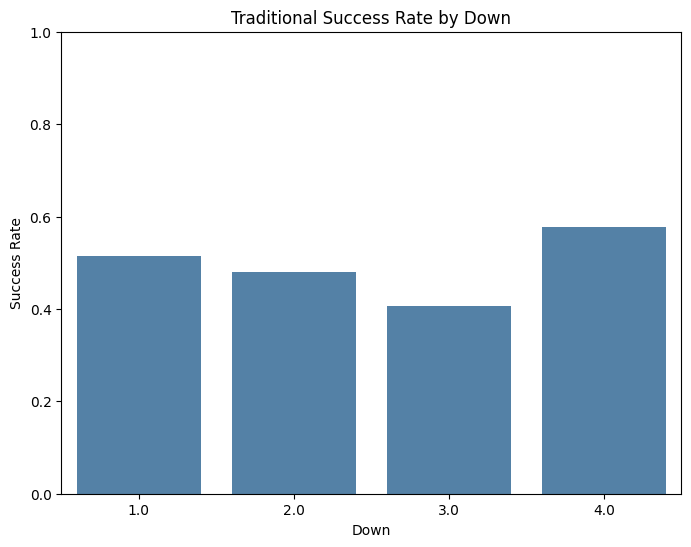

In [6]:
# calculate conversion percentage

# apply traditional benchmark thresholds based on the current down
recent_pbp = recent_pbp.with_columns(
    pl.when(pl.col('down') == 1.0).then(0.40)
    .when(pl.col('down') == 2.0).then(0.60)
    .when(pl.col('down').is_in([3.0, 4.0])).then(1.0)
    .otherwise(None)
    .alias('benchmark_threshold_pct')
).with_columns(
    # create binary success indicator
    pl.when(pl.col('conversion_pct_gained') >= pl.col('benchmark_threshold_pct'))
    .then(1)
    .otherwise(0)
    .alias('is_success_benchmark')
)

# preview the engineered columns
print("--- Traditional Success Preview ---")
display(recent_pbp.select([
    'down', 'ydstogo', 'yards_gained', 'conversion_pct_gained',
    'benchmark_threshold_pct', 'is_success_benchmark'
]).head())

# save the aggregated data to a variable instead of computing it inside the display function
success_by_down = recent_pbp.group_by('down').agg(
    pl.col('is_success_benchmark').mean().round(3).alias('traditional_success_rate')
).drop_nulls('down').sort('down')

# display the aggregated table
print("\n--- Traditional Success Rate by Down ---")
display(success_by_down)

# Calculate the standard deviation of 'revised_success_rate'
std_dev_traditional_success_rate = success_by_down.filter(pl.col('down').is_in([1.0, 2.0, 3.0]))['traditional_success_rate'].std()
print(f"Standard Deviation of Traditional Success Rate (Downs 1-3): {std_dev_traditional_success_rate:.4f}")

# extract polars columns directly to lists to bypass pandas conversion
downs_list = success_by_down['down'].to_list()
rates_list = success_by_down['traditional_success_rate'].to_list()

# build the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=downs_list, y=rates_list, color='steelblue')
plt.title('Traditional Success Rate by Down')
plt.xlabel('Down')
plt.ylabel('Success Rate')
plt.ylim(0, 1.0)
plt.show()

In [7]:
# calculate alignment of success rate with positive epa plays

# 2. Create a cross-tabulation to compare the two metrics
print("--- Cross-Tabulation: Benchmark vs. Positive EPA ---")
comparison_matrix = recent_pbp .group_by(['is_success_benchmark', 'is_pos_epa']).len().sort(['is_success_benchmark', 'is_pos_epa'])
display(comparison_matrix)

# 3. Calculate the overall agreement rate
# How often does the traditional benchmark correctly identify a positive EPA play?
agreement_df = recent_pbp .with_columns(
    pl.when(pl.col('is_success_benchmark') == pl.col('is_pos_epa'))
    .then(1)
    .otherwise(0)
    .alias('metrics_agree')
)

agreement_rate = agreement_df['metrics_agree'].mean()
print(f"\nOverall Agreement Rate: {agreement_rate:.2%}")

# 4. Investigate the Disagreements (The "Inefficiencies")
# Let's look at plays that were a traditional "Success" but had NEGATIVE EPA
false_positives = recent_pbp .filter(
    (pl.col('is_success_benchmark') == 1) & (pl.col('is_pos_epa') == 0)
)
print(f"\nTotal Traditional 'Successes' that resulted in Negative EPA: {false_positives.height}")

--- Cross-Tabulation: Benchmark vs. Positive EPA ---


is_success_benchmark,is_pos_epa,len
i32,i32,u32
0,0,64070
0,1,2040
1,0,7527
1,1,53869



Overall Agreement Rate: 92.50%

Total Traditional 'Successes' that resulted in Negative EPA: 7527


In [8]:
# check other metrics for agreement rate beyond accuracy

# isolate ground truth and prediction columns dropping any nulls to ensure clean math
evaluation_metrics = recent_pbp .select([
    pl.col('is_pos_epa').alias('actual'),
    pl.col('is_success_benchmark').alias('predicted') # Changed 'rev_sr_play' to 'is_success_benchmark'
]).drop_nulls()

# extract true labels and predictions to numpy arrays for scikit learn compatibility
y_true = evaluation_metrics['actual'].to_numpy()
y_pred = evaluation_metrics['predicted'].to_numpy()

# calculate confusion matrix
# scikit learn returns an array structured as true negatives false positives then false negatives true positives
conf_matrix = confusion_matrix(y_true, y_pred)

tn = conf_matrix[0, 0]
fp = conf_matrix[0, 1]
fn = conf_matrix[1, 0]
tp = conf_matrix[1, 1]

# calculate classification metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f_one_score = f1_score(y_true, y_pred)

# output the formatted results
print("--- Confusion Matrix ---")
print(f"True Positives (Correctly labeled Success): {tp}")
print(f"False Positives (Labeled Success but negative EPA): {fp}")
print(f"True Negatives (Correctly labeled Failure): {tn}")
print(f"False Negatives (Labeled Failure but positive EPA): {fn}")

print("\n--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f_one_score:.4f}")

--- Confusion Matrix ---
True Positives (Correctly labeled Success): 53869
False Positives (Labeled Success but negative EPA): 7527
True Negatives (Correctly labeled Failure): 64070
False Negatives (Labeled Failure but positive EPA): 2040

--- Classification Metrics ---
Accuracy:  0.9250
Precision: 0.8774
Recall:    0.9635
F1 Score:  0.9184


# Analysis - Success Rate

--- Empirical Crossover Points based on Average EPA ---


down,pct_gained_bin,avg_epa,total_plays
f64,f64,f64,u32
1.0,0.5,0.036996,3710
2.0,0.6,0.010762,2070
3.0,0.9,0.25835,222
4.0,1.0,2.579473,1341


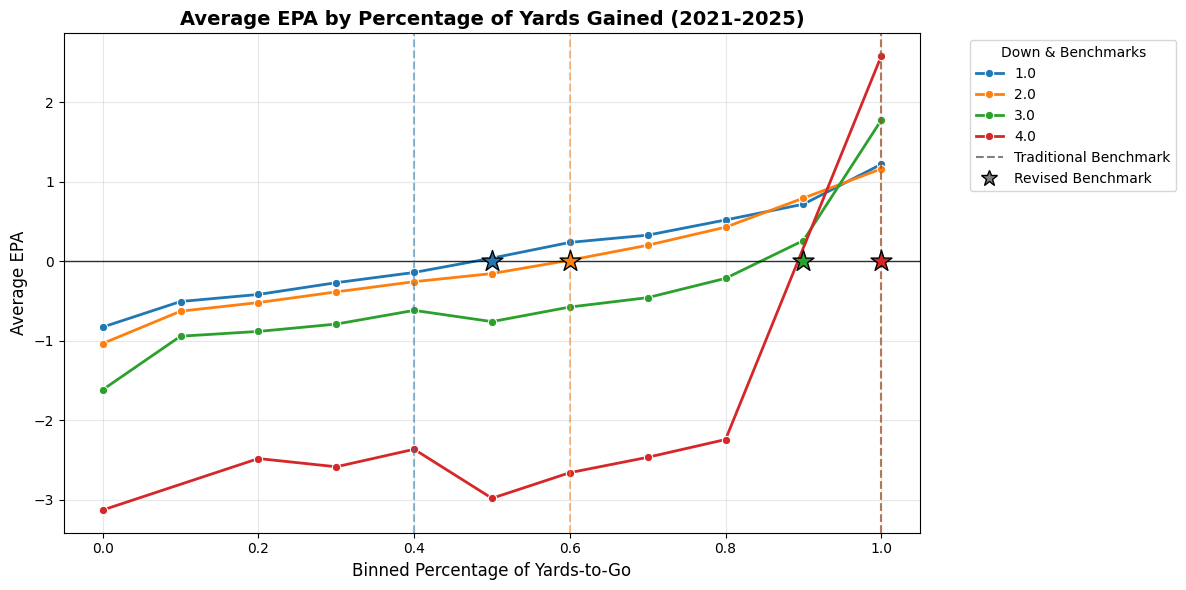

In [9]:


# group data by down and bin to calculate average epa and filter low sample sizes
grouped_df = (
    recent_pbp.filter(pl.col('down').is_in([1.0, 2.0, 3.0, 4.0]))
    .group_by(['down', 'pct_gained_bin'], maintain_order=True)
    .agg([
        pl.col('epa').mean().alias('avg_epa'),
        pl.col('epa').count().alias('total_plays')
    ])
    .filter(pl.col('total_plays') >= 2)
    .sort(['down', 'pct_gained_bin'])
)

# find minimum bin for each down yielding positive average epa
optimal_bins = (
    grouped_df
    .filter(pl.col('avg_epa') > 0.0)
    .sort(['down', 'pct_gained_bin'])
    .group_by('down', maintain_order=True)
    .head(1)
)

print("--- Empirical Crossover Points based on Average EPA ---")
display(optimal_bins)

# convert to dictionary to bypass pandas conversion overhead for seaborn
plot_data = grouped_df.to_dict(as_series=False)

# define legacy benchmarks for visual comparison
legacy_benchmarks = {1.0: 0.4, 2.0: 0.6, 3.0: 1.0, 4.0: 1.0}

# visualize discrete bins
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=plot_data,
    x='pct_gained_bin',
    y='avg_epa',
    hue='down',
    palette='tab10',
    marker='o',
    linewidth=2
)

# add baseline at zero epa to visually show crossover point
plt.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

# overlay benchmark indicators dynamically matching seaborn palette
colors = sns.color_palette('tab10', n_colors=4)

for i, down in enumerate([1.0, 2.0, 3.0, 4.0]):
    color = colors[i]

    trad_x = legacy_benchmarks[down]
    plt.axvline(x=trad_x, color=color, linestyle='--', alpha=0.5)

    revised_df = optimal_bins.filter(pl.col('down') == down)
    if len(revised_df) > 0:
        revised_x = revised_df['pct_gained_bin'][0]
        plt.scatter(x=revised_x, y=0, color=color, marker='*', s=250, zorder=5, edgecolors='black')

# update title to reflect target seasons and average metric
plt.title('Average EPA by Percentage of Yards Gained (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Binned Percentage of Yards-to-Go', fontsize=12)
plt.ylabel('Average EPA', fontsize=12)

# customize legend to explain new visual elements
handles, labels = ax.get_legend_handles_labels()
trad_line = mlines.Line2D([], [], color='gray', linestyle='--', label='Traditional Benchmark')
rev_star = mlines.Line2D([], [], color='gray', marker='*', linestyle='None', markersize=12, markeredgecolor='black', label='Revised Benchmark')
handles.extend([trad_line, rev_star])

plt.legend(handles=handles, title='Down & Benchmarks', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Historical Crossover Points (>0.0 Average EPA) ---


season,down,pct_gained_bin,avg_epa,total_plays
i32,f64,f64,f64,u32
2021,1.0,0.5,0.049596,688
2021,2.0,0.6,0.00009,415
2021,3.0,0.9,0.295494,44
2021,4.0,1.0,2.503259,258
2022,1.0,0.5,0.054977,767


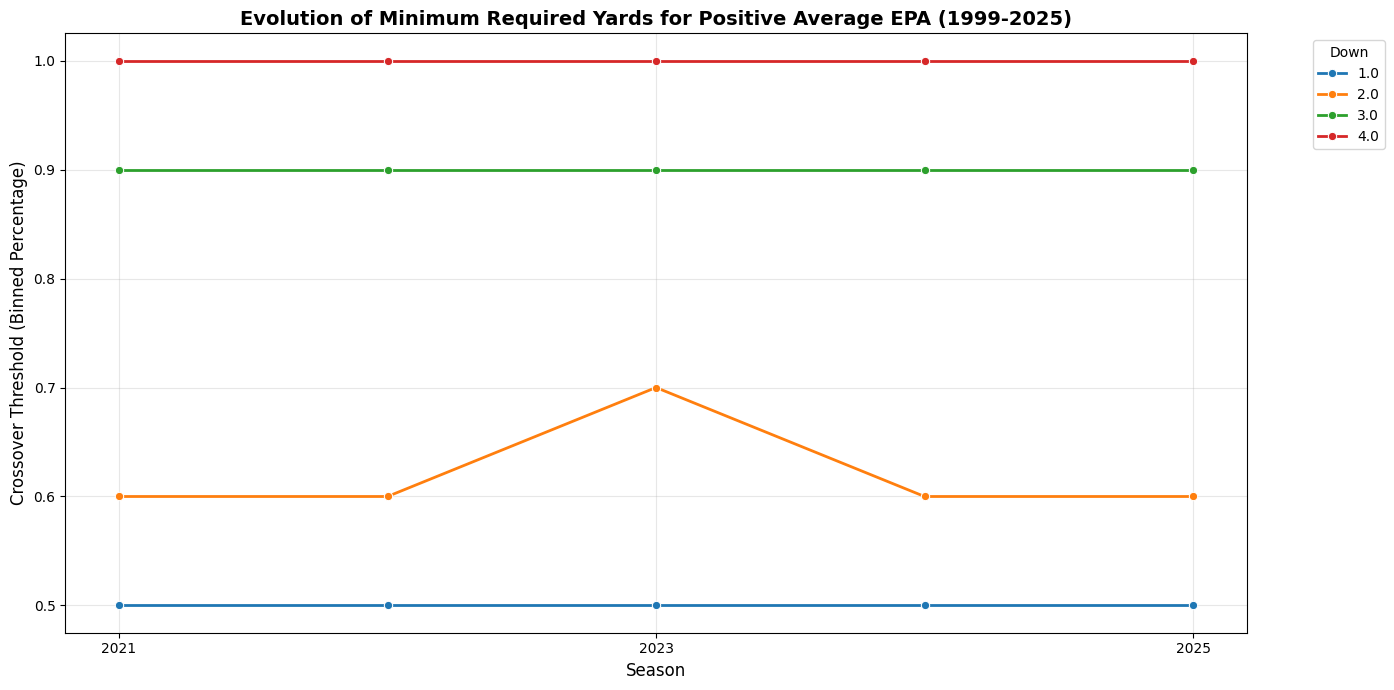

In [10]:
# calculate yardage thresholds by season from 1999-2025 - by avg EPA

# group global data by season down and bin to calculate average epa
grouped_avg_time_df = (
    pbp.filter(pl.col('down').is_in([1.0, 2.0, 3.0, 4.0]))
    .group_by(['season', 'down', 'pct_gained_bin'], maintain_order=True)
    .agg([
        pl.col('epa').mean().alias('avg_epa'),
        pl.col('epa').count().alias('total_plays')
    ])
    .filter(pl.col('total_plays') >= 2)
    .sort(['season', 'down', 'pct_gained_bin'])
)

# find minimum bin per season and down yielding positive average epa
historical_crossover_avg_bins = (
    grouped_avg_time_df
    .filter(pl.col('avg_epa') > 0.0)
    .sort(['season', 'down', 'pct_gained_bin'])
    .group_by(['season', 'down'], maintain_order=True)
    .head(1)
)

print("--- Historical Crossover Points (>0.0 Average EPA) ---")
display(historical_crossover_avg_bins.select(['season', 'down', 'pct_gained_bin', 'avg_epa', 'total_plays']).head())

# convert to dictionary to bypass pandas conversion overhead for seaborn
plot_avg_time_data = historical_crossover_avg_bins.to_dict(as_series=False)

# visualize the crossover thresholds over time
plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=plot_avg_time_data,
    x='season',
    y='pct_gained_bin',
    hue='down',
    palette='tab10',
    marker='o',
    linewidth=2
)

# dynamically generate x axis ticks to prevent label overlap
min_season = min(plot_avg_time_data['season'])
max_season = max(plot_avg_time_data['season'])
plt.xticks(range(min_season, max_season + 1, 2))

# update title and labels
plt.title('Evolution of Minimum Required Yards for Positive Average EPA (1999-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Crossover Threshold (Binned Percentage)', fontsize=12)
plt.legend(title='Down', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Empirical Crossover Points (>50% Positive EPA Rate) ---


down,pct_gained_bin,positive_epa_pct,total_plays
f64,f64,f64,u32
1.0,0.5,0.67035,3710
2.0,0.7,0.812072,1607
3.0,0.9,0.671171,222
4.0,1.0,0.98956,1341


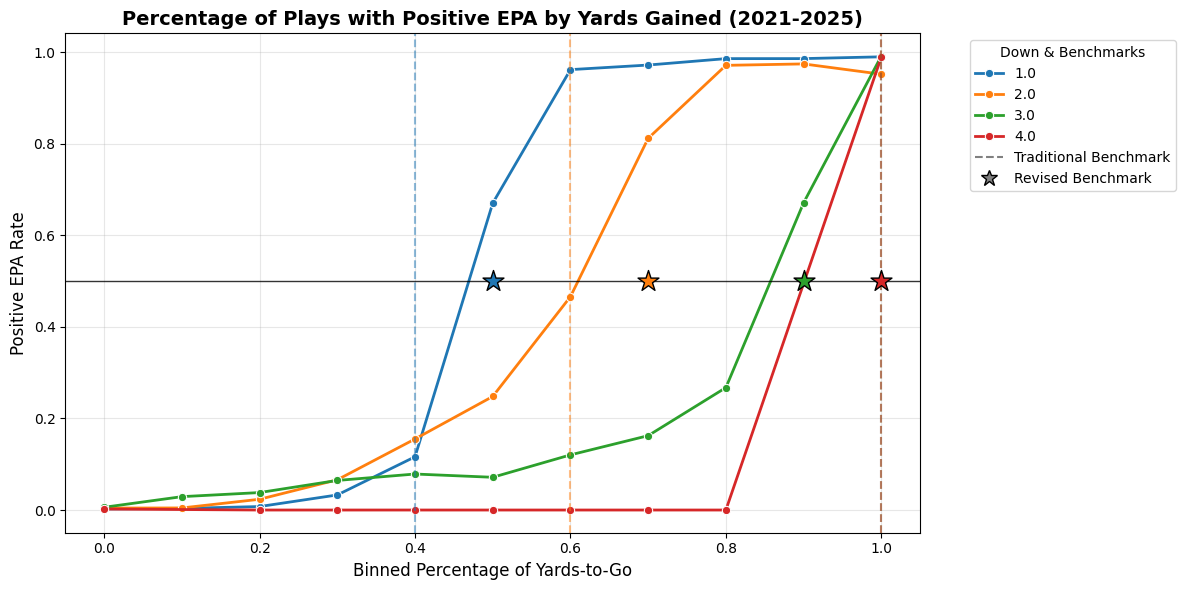

In [11]:
# group data by down and bin to calculate positive epa rates and filter low sample sizes
grouped_pct_df = (
    recent_pbp.filter(pl.col('down').is_in([1.0, 2.0, 3.0, 4.0]))
    .group_by(['down', 'pct_gained_bin'], maintain_order=True)
    .agg([
        pl.col('is_pos_epa').sum().alias('positive_epa_count'),
        pl.col('is_pos_epa').count().alias('total_plays')
    ])
    .with_columns(
        (pl.col('positive_epa_count') / pl.col('total_plays')).alias('positive_epa_pct')
    )
    .filter(pl.col('total_plays') >= 2)
    .sort(['down', 'pct_gained_bin'])
)

# find minimum bin for each down yielding a positive epa rate greater than half
optimal_pct_bins = (
    grouped_pct_df
    .filter(pl.col('positive_epa_pct') > 0.5)
    .sort(['down', 'pct_gained_bin'])
    .group_by('down', maintain_order=True)
    .head(1)
)

print("--- Empirical Crossover Points (>50% Positive EPA Rate) ---")
display(optimal_pct_bins.select(['down', 'pct_gained_bin', 'positive_epa_pct', 'total_plays']))

# convert to dictionary to bypass pandas conversion overhead for seaborn
plot_pct_data = grouped_pct_df.to_dict(as_series=False)

# define legacy benchmarks for visual comparison
legacy_benchmarks = {1.0: 0.4, 2.0: 0.6, 3.0: 1.0, 4.0: 1.0}

# visualize discrete bins
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=plot_pct_data,
    x='pct_gained_bin',
    y='positive_epa_pct',
    hue='down',
    palette='tab10',
    marker='o',
    linewidth=2
)

# add baseline at break-even rate to visually show crossover point
plt.axhline(y=0.5, color='black', linestyle='-', linewidth=1, alpha=0.8)

# overlay benchmark indicators dynamically matching seaborn palette
colors = sns.color_palette('tab10', n_colors=4)

for i, down in enumerate([1.0, 2.0, 3.0, 4.0]):
    color = colors[i]

    trad_x = legacy_benchmarks[down]
    plt.axvline(x=trad_x, color=color, linestyle='--', alpha=0.5)

    revised_df = optimal_pct_bins.filter(pl.col('down') == down)
    if len(revised_df) > 0:
        revised_x = revised_df['pct_gained_bin'][0]
        plt.scatter(x=revised_x, y=0.5, color=color, marker='*', s=250, zorder=5, edgecolors='black')

# update title to reflect target seasons and rate metric
plt.title('Percentage of Plays with Positive EPA by Yards Gained (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Binned Percentage of Yards-to-Go', fontsize=12)
plt.ylabel('Positive EPA Rate', fontsize=12)

# customize legend to explain new visual elements
handles, labels = ax.get_legend_handles_labels()
trad_line = mlines.Line2D([], [], color='gray', linestyle='--', label='Traditional Benchmark')
rev_star = mlines.Line2D([], [], color='gray', marker='*', linestyle='None', markersize=12, markeredgecolor='black', label='Revised Benchmark')
handles.extend([trad_line, rev_star])

plt.legend(handles=handles, title='Down & Benchmarks', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

--- Historical Crossover Points (>50% Positive EPA Rate) ---


season,down,pct_gained_bin,positive_epa_pct,total_plays
i32,f64,f64,f64,u32
2021,1.0,0.5,0.688953,688
2021,2.0,0.7,0.831081,296
2021,3.0,0.9,0.772727,44
2021,4.0,1.0,0.98062,258
2022,1.0,0.5,0.688396,767


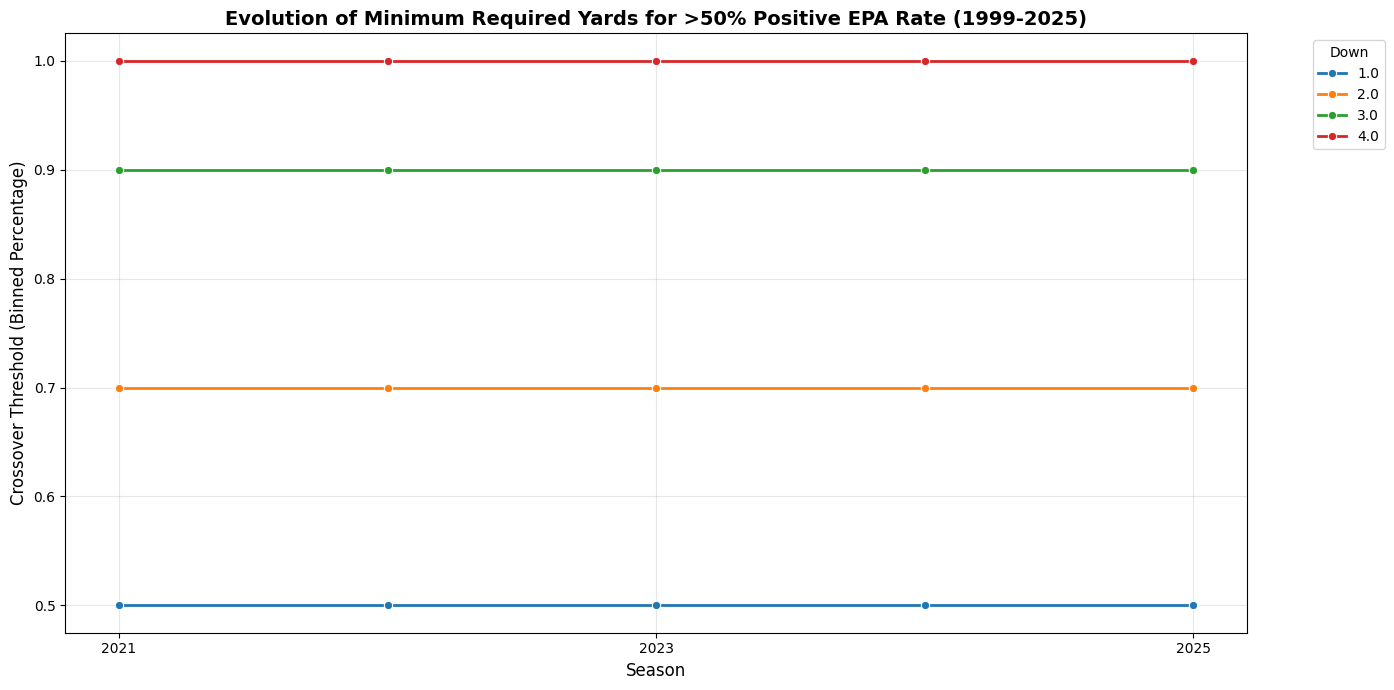

In [12]:
# calculate yardage thresholds by season from 1999-2025 - by % of plays with positive EPA

# group global data by season, down, and bin to calculate positive epa rates
grouped_time_df = (
    pbp.filter(pl.col('down').is_in([1.0, 2.0, 3.0, 4.0]))
    .group_by(['season', 'down', 'pct_gained_bin'], maintain_order=True)
    .agg([
        pl.col('is_pos_epa').sum().alias('positive_epa_count'),
        pl.col('is_pos_epa').count().alias('total_plays')
    ])
    .with_columns(
        (pl.col('positive_epa_count') / pl.col('total_plays')).alias('positive_epa_pct')
    )
    .filter(pl.col('total_plays') >= 2)
    .sort(['season', 'down', 'pct_gained_bin'])
)

# find minimum bin per season and down yielding a positive epa rate greater than half
historical_crossover_bins = (
    grouped_time_df
    .filter(pl.col('positive_epa_pct') > 0.5)
    .sort(['season', 'down', 'pct_gained_bin'])
    .group_by(['season', 'down'], maintain_order=True)
    .head(1)
)

print("--- Historical Crossover Points (>50% Positive EPA Rate) ---")
display(historical_crossover_bins.select(['season', 'down', 'pct_gained_bin', 'positive_epa_pct', 'total_plays']).head())

# convert to dictionary to bypass pandas conversion overhead for seaborn
plot_time_data = historical_crossover_bins.to_dict(as_series=False)

# visualize the crossover thresholds over time
plt.figure(figsize=(14, 7))
ax = sns.lineplot(
    data=plot_time_data,
    x='season',
    y='pct_gained_bin',
    hue='down',
    palette='tab10',
    marker='o',
    linewidth=2
)

# dynamically generate x-axis ticks to prevent label overlap
min_season = min(plot_time_data['season'])
max_season = max(plot_time_data['season'])
plt.xticks(range(min_season, max_season + 1, 2))

# update title and labels
plt.title('Evolution of Minimum Required Yards for >50% Positive EPA Rate (1999-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Crossover Threshold (Binned Percentage)', fontsize=12)
plt.legend(title='Down', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Explosive Plays

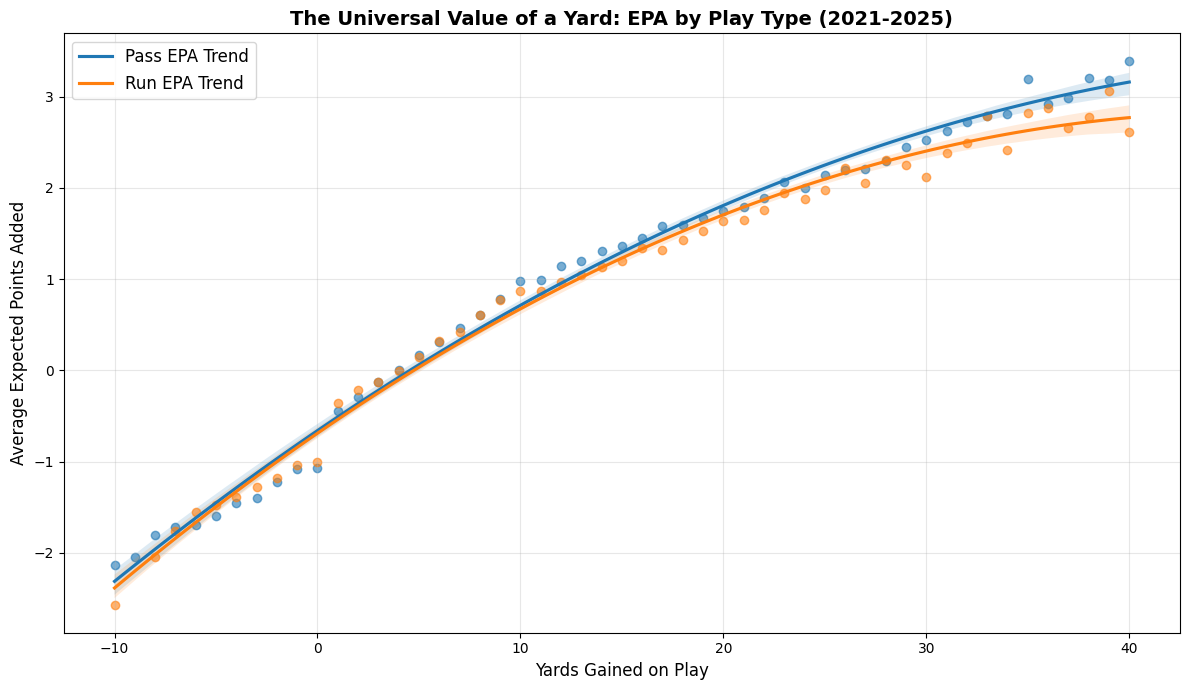

In [13]:
def analyze_epa_by_yardage(pbp_data):
    # filter for standard yardage bounds to keep the focus on typical outcomes
    recent_pbp = pbp_data.filter(
        (pl.col('yards_gained') >= -10.0) &
        (pl.col('yards_gained') <= 40.0)
    )

    # calculate the average epa for every specific yardage amount
    epa_df = recent_pbp.group_by(['yards_gained', 'play_type']).agg([
        pl.col('epa').mean().alias('mean_epa'),
        pl.col('play_id').count().alias('play_count')
    ])

    # filter out anomalous yardages with low sample sizes to keep the curve smooth
    filtered_epa = epa_df.filter(pl.col('play_count') >= 10)

    return filtered_epa

# generate aggregated data
epa_curve_data = analyze_epa_by_yardage(recent_pbp)
plot_data = epa_curve_data.to_pandas()

# visualize the overlapping value curves
plt.figure(figsize=(12, 7))
sns.regplot(
    data=plot_data[plot_data['play_type'] == 'pass'],
    x='yards_gained',
    y='mean_epa',
    scatter_kws={'alpha':0.6, 'color':'#1f77b4'},
    line_kws={'color':'#1f77b4', 'label':'Pass EPA Trend'},
    order=2
)

sns.regplot(
    data=plot_data[plot_data['play_type'] == 'run'],
    x='yards_gained',
    y='mean_epa',
    scatter_kws={'alpha':0.6, 'color':'#ff7f0e'},
    line_kws={'color':'#ff7f0e', 'label':'Run EPA Trend'},
    order=2
)

plt.title('The Universal Value of a Yard: EPA by Play Type (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Yards Gained on Play', fontsize=12)
plt.ylabel('Average Expected Points Added', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

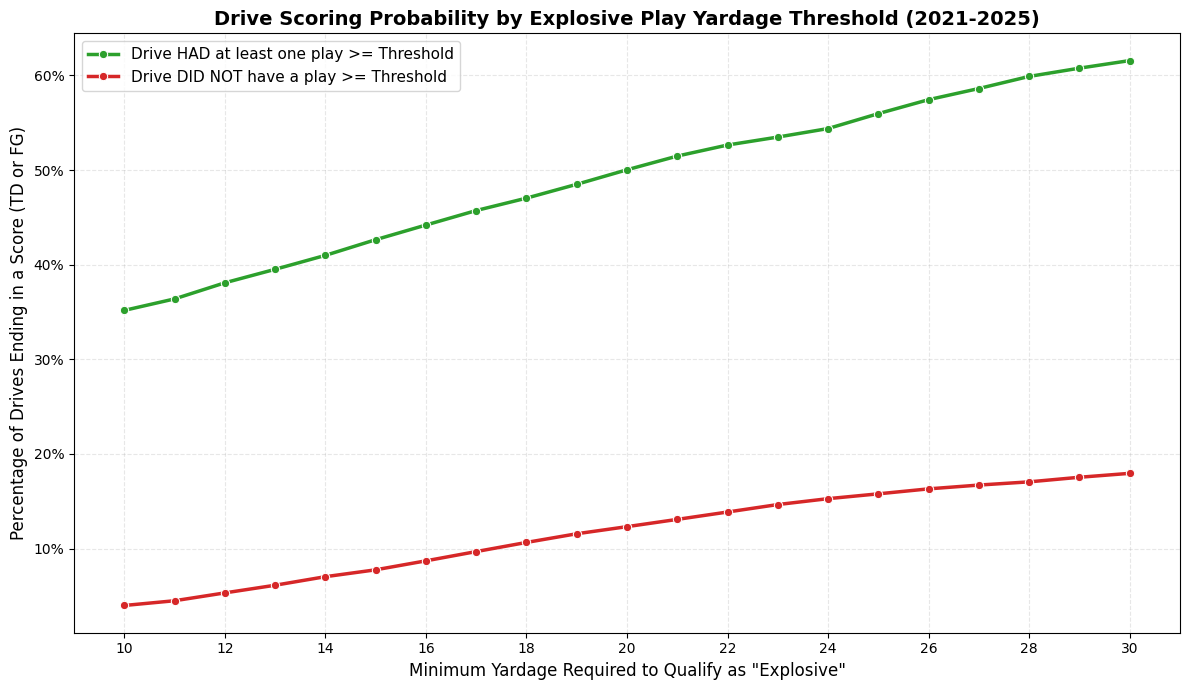

 Explosive Threshold (Yards) Score % (With Explosive Play) Score % (Without Explosive Play)
                          10                         35.2%                             4.0%
                          12                         38.1%                             5.3%
                          14                         41.0%                             7.0%
                          16                         44.2%                             8.7%
                          18                         47.0%                            10.7%
                          20                         50.0%                            12.3%
                          22                         52.6%                            13.9%
                          24                         54.4%                            15.3%
                          26                         57.4%                            16.3%
                          28                         59.9%                      

In [14]:

def calculate_scoring_rate_by_threshold(pbp_data):
    # Filter for valid plays and drives that have a definitive outcome
    # Note: fixed_drive_result is a categorical label applied to every play in a drive
    drive_level_data = pbp_data.filter(
        (pl.col('drive').is_not_null()) &
        (pl.col('fixed_drive_result').is_not_null())
    )

    # Aggregate to the drive level: Find the longest play on the drive and the drive's result
    drive_df = drive_level_data.group_by(['game_id', 'drive']).agg([
        pl.col('yards_gained').max().alias('max_play_yards'),
        pl.col('fixed_drive_result').first().alias('drive_result')
    ])

    # Flag if the drive ended in a Touchdown or Field Goal
    drive_df = drive_df.with_columns(
        pl.when(pl.col('drive_result').is_in(['Touchdown', 'Field Goal']))
        .then(1)
        .otherwise(0)
        .alias('scored')
    )

    results = []

    # Loop through the 10 to 30 yard thresholds
    for threshold in range(10, 31):
        # Calculate rates natively in Polars before appending to results
        drives_with = drive_df.filter(pl.col('max_play_yards') >= threshold)
        drives_without = drive_df.filter(pl.col('max_play_yards') < threshold)

        score_rate_with = drives_with['scored'].mean() if drives_with.height > 0 else 0
        score_rate_without = drives_without['scored'].mean() if drives_without.height > 0 else 0

        results.append({
            'Explosive Threshold (Yards)': threshold,
            'Score % (With Explosive Play)': score_rate_with,
            'Score % (Without Explosive Play)': score_rate_without,
            'Drives with Explosive Play': drives_with.height
        })

    return pl.DataFrame(results)

# Execute the calculation using the master recent_pbp dataframe
results_df = calculate_scoring_rate_by_threshold(recent_pbp)

# Convert to pandas for visualization
plot_results_df = results_df.to_pandas()

# Visualize the scaling impact of explosive plays
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=plot_results_df,
    x='Explosive Threshold (Yards)',
    y='Score % (With Explosive Play)',
    marker='o',
    label='Drive HAD at least one play >= Threshold',
    linewidth=2.5,
    color='#2ca02c'
)
sns.lineplot(
    data=plot_results_df,
    x='Explosive Threshold (Yards)',
    y='Score % (Without Explosive Play)',
    marker='o',
    label='Drive DID NOT have a play >= Threshold',
    linewidth=2.5,
    color='#d62728'
)

plt.title('Drive Scoring Probability by Explosive Play Yardage Threshold (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Yardage Required to Qualify as "Explosive"', fontsize=12)
plt.ylabel('Percentage of Drives Ending in a Score (TD or FG)', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(range(10, 31, 2))
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Print diagnostic summary (every other row for readability)
display_df = plot_results_df[['Explosive Threshold (Yards)', 'Score % (With Explosive Play)', 'Score % (Without Explosive Play)']].copy()
display_df['Score % (With Explosive Play)'] = display_df['Score % (With Explosive Play)'].apply(lambda x: f"{x*100:.1f}%")
display_df['Score % (Without Explosive Play)'] = display_df['Score % (Without Explosive Play)'].apply(lambda x: f"{x*100:.1f}%")
print(display_df.iloc[::2].to_string(index=False))

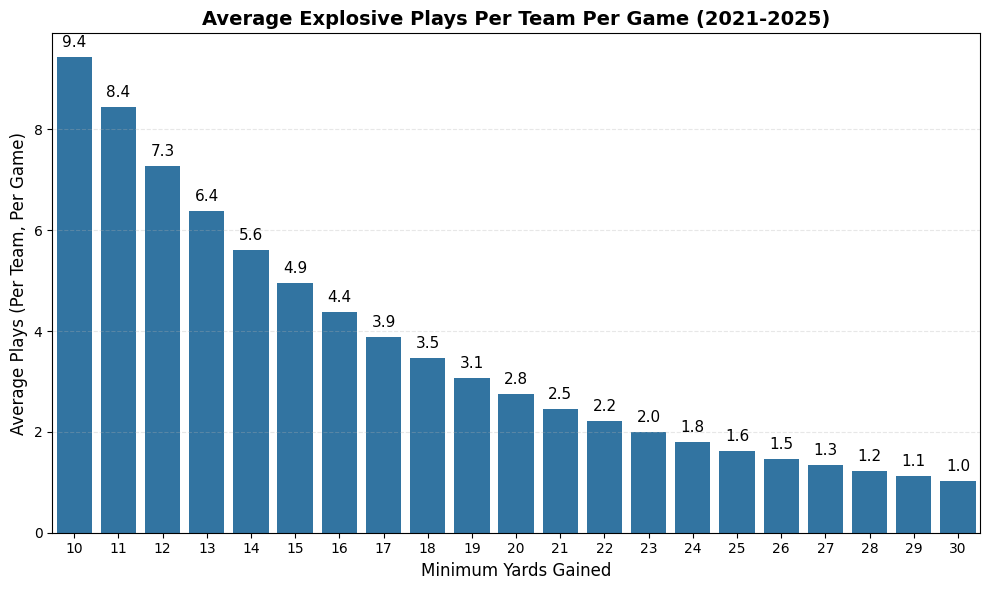

shape: (21, 2)
┌───────────────────┬─────────────────────────┐
│ Yardage Threshold ┆ Plays Per Team Per Game │
│ ---               ┆ ---                     │
│ i64               ┆ f64                     │
╞═══════════════════╪═════════════════════════╡
│ 10                ┆ 9.432671                │
│ 11                ┆ 8.437086                │
│ 12                ┆ 7.276306                │
│ 13                ┆ 6.384474                │
│ 14                ┆ 5.608536                │
│ …                 ┆ …                       │
│ 26                ┆ 1.461737                │
│ 27                ┆ 1.33738                 │
│ 28                ┆ 1.233996                │
│ 29                ┆ 1.121781                │
│ 30                ┆ 1.026858                │
└───────────────────┴─────────────────────────┘


In [29]:
def calculate_explosive_play_frequency(pbp_data):
    # calculate total number of team-games in the dataset
    # a team-game is one team playing one game
    team_games = pbp_data.select(['game_id', 'posteam']).unique().height

    results = []

    # iterate through thresholds from 10 to 30 in increments of 2
    for threshold in range(10, 31):

        # count total plays meeting the threshold
        total_explosive_plays = pbp_data.filter(pl.col('yards_gained') >= threshold).height

        # calculate average per team per game
        avg_per_game = total_explosive_plays / team_games

        results.append({
            'Yardage Threshold': threshold,
            'Plays Per Team Per Game': avg_per_game
        })

    return pl.DataFrame(results)

# execute calculation using the master recent_pbp dataframe
freq_df = calculate_explosive_play_frequency(recent_pbp)

# convert to pandas strictly for seaborn compatibility
plot_df = freq_df.to_pandas()

# visualize the distribution
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=plot_df,
    x='Yardage Threshold',
    y='Plays Per Team Per Game',
    color='#1f77b4'
)

# add data labels to the top of each bar
for i, p in enumerate(ax.patches):
    ax.annotate(f"{plot_df['Plays Per Team Per Game'].iloc[i]:.1f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), textcoords='offset points')

plt.title('Average Explosive Plays Per Team Per Game (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Yards Gained', fontsize=12)
plt.ylabel('Average Plays (Per Team, Per Game)', fontsize=12)
plt.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# print the raw numbers
print(freq_df)

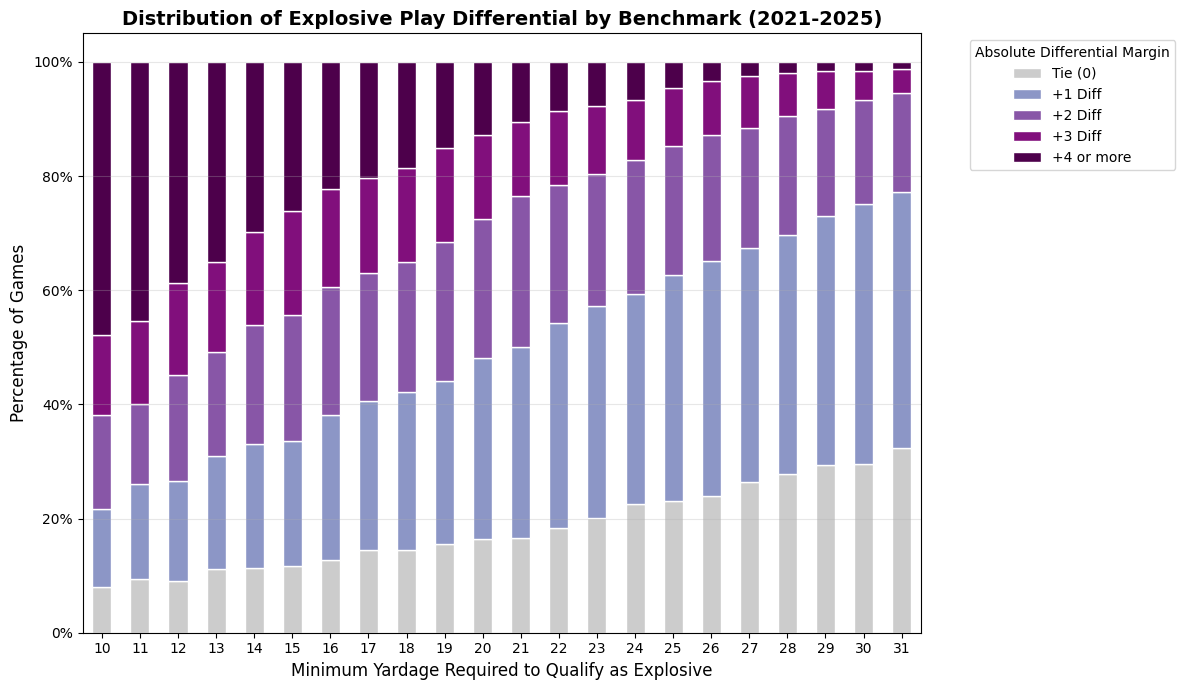

In [30]:
import matplotlib.ticker as mtick
def calculate_differential_distribution(pbp_data):
    # identify every team involved in every game within the dataset
    games = pbp_data.select(['game_id', 'home_team', 'away_team']).unique()
    all_teams_per_game = pl.concat([
        games.select(['game_id', pl.col('home_team').alias('team')]),
        games.select(['game_id', pl.col('away_team').alias('team')])
    ])

    results = []
    yardage_thresholds = list(range(10, 32))

    for y_thresh in yardage_thresholds:
        # identify plays meeting the specific yardage threshold
        recent_pbp_internal = pbp_data.with_columns(
            pl.when(pl.col('yards_gained') >= y_thresh).then(1)
            .otherwise(0).alias('is_explosive')
        )

        # sum explosive plays per team per game
        team_game_explosive = recent_pbp_internal.group_by(['game_id', 'posteam']).agg(
            pl.col('is_explosive').sum().alias('explosive_plays')
        ).rename({"posteam": "team"})

        # join with the master list to include teams with zero explosive plays
        merged = all_teams_per_game.join(team_game_explosive, on=['game_id', 'team'], how='left').fill_null(0)

        # align opponents to calculate the absolute differential
        opponents = merged.select([
            pl.col('game_id'),
            pl.col('team').alias('opp_team'),
            pl.col('explosive_plays').alias('opp_explosive_plays')
        ])

        matchups = merged.join(opponents, on='game_id').filter(pl.col('team') != pl.col('opp_team'))

        matchups = matchups.with_columns(
            (pl.col('explosive_plays') - pl.col('opp_explosive_plays')).abs().alias('abs_diff')
        )

        # calculate frequency of each differential margin
        total_team_games = matchups.height

        results.append({
            'Threshold': y_thresh,
            'Tie (0)': matchups.filter(pl.col('abs_diff') == 0).height / total_team_games,
            '+1 Diff': matchups.filter(pl.col('abs_diff') == 1).height / total_team_games,
            '+2 Diff': matchups.filter(pl.col('abs_diff') == 2).height / total_team_games,
            '+3 Diff': matchups.filter(pl.col('abs_diff') == 3).height / total_team_games,
            '+4 or more': matchups.filter(pl.col('abs_diff') >= 4).height / total_team_games
        })

    return pl.DataFrame(results)

# execute calculation using the master dataframe
dist_df = calculate_differential_distribution(recent_pbp)

# convert to pandas for stacked bar plotting
plot_dist_df = dist_df.to_pandas()

# visualize stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))

# clean sequential color palette
colors = ['#cccccc', '#8c96c6', '#8856a7', '#810f7c', '#4d004b', 'black']
plot_dist_df.set_index('Threshold').plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='white')

plt.title('Distribution of Explosive Play Differential by Benchmark (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Minimum Yardage Required to Qualify as Explosive', fontsize=12)
plt.ylabel('Percentage of Games', fontsize=12)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title='Absolute Differential Margin', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:

def analyze_season_level_metrics(pbp_data):
    # apply metric logic to the master dataframe
    # note: we use conversion_pct_gained which was engineered in previous steps
    pbp_with_metrics = pbp_data.with_columns([
        # traditional success rate (40/60/100)
        pl.when((pl.col('down') == 1.0) & (pl.col('conversion_pct_gained') >= 0.4)).then(1)
          .when((pl.col('down') == 2.0) & (pl.col('conversion_pct_gained') >= 0.6)).then(1)
          .when((pl.col('down') == 3.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .when((pl.col('down') == 4.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .otherwise(0).alias('trad_sr_play'),

        # traditional explosive plays (Run 12+, Pass 16+)
        pl.when((pl.col('play_type') == 'run') & (pl.col('yards_gained') >= 12.0)).then(1)
          .when((pl.col('play_type') == 'pass') & (pl.col('yards_gained') >= 16.0)).then(1)
          .otherwise(0).alias('trad_exp_play'),

        # revised success rate (50/70/90/100 based on median EPA analysis)
        pl.when((pl.col('down') == 1.0) & (pl.col('conversion_pct_gained') >= 0.5)).then(1)
          .when((pl.col('down') == 2.0) & (pl.col('conversion_pct_gained') >= 0.7)).then(1)
          .when((pl.col('down') == 3.0) & (pl.col('conversion_pct_gained') >= 0.9)).then(1)
          .when((pl.col('down') == 4.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .otherwise(0).alias('rev_sr_play'),

        # revised explosive plays (agnostic 15+)
        pl.when(pl.col('yards_gained') >= 15.0).then(1)
          .otherwise(0).alias('rev_exp_play')
    ])

    # aggregate offensive stats by season
    offense_stats = pbp_with_metrics.group_by(['season', 'posteam']).agg([
        pl.col('trad_sr_play').mean().alias('off_trad_sr'),
        (pl.col('trad_exp_play').sum() / pl.col('game_id').n_unique()).alias('off_trad_exp_pg'),
        pl.col('rev_sr_play').mean().alias('off_rev_sr'),
        (pl.col('rev_exp_play').sum() / pl.col('game_id').n_unique()).alias('off_rev_exp_pg')
    ]).rename({"posteam": "team"})

    # aggregate defensive stats by season
    defense_stats = pbp_with_metrics.group_by(['season', 'defteam']).agg([
        pl.col('trad_sr_play').mean().alias('def_trad_sr'),
        (pl.col('trad_exp_play').sum() / pl.col('game_id').n_unique()).alias('def_trad_exp_pg'),
        pl.col('rev_sr_play').mean().alias('def_rev_sr'),
        (pl.col('rev_exp_play').sum() / pl.col('game_id').n_unique()).alias('def_rev_exp_pg')
    ]).rename({"defteam": "team"})

    # extract scoring totals directly from pbp data for architectural consistency
    games = pbp_data.group_by(['season', 'game_id', 'home_team', 'away_team']).agg([
        pl.col('home_score').max().alias('home_final'),
        pl.col('away_score').max().alias('away_final')
    ])

    home_pts = games.select([
        'season',
        pl.col('home_team').alias('team'),
        pl.col('home_final').alias('pts_for'),
        pl.col('away_final').alias('pts_against')
    ])

    away_pts = games.select([
        'season',
        pl.col('away_team').alias('team'),
        pl.col('away_final').alias('pts_for'),
        pl.col('home_final').alias('pts_against')
    ])

    season_points = pl.concat([home_pts, away_pts]).group_by(['season', 'team']).agg([
        pl.col('pts_for').mean().alias('ppg_for'),
        pl.col('pts_against').mean().alias('ppg_against')
    ])

    # final table join
    master_df = season_points.join(offense_stats, on=['season', 'team']).join(defense_stats, on=['season', 'team']).to_pandas()
    return master_df

# perform calculations
df_season = analyze_season_level_metrics(recent_pbp)

def run_comparison(df, y_col, metrics_type):
    if metrics_type == 'trad':
        x_cols = ['off_trad_sr', 'off_trad_exp_pg'] if 'for' in y_col else ['def_trad_sr', 'def_trad_exp_pg']
        title = "TRADITIONAL (40/60/100 SR | Split Explosive)"
    else:
        x_cols = ['off_rev_sr', 'off_rev_exp_pg'] if 'for' in y_col else ['def_rev_sr', 'def_rev_exp_pg']
        title = "REVISED (50/70/90/100 SR | Agnostic 15+)"

    X = sm.add_constant(df[x_cols])
    model = sm.OLS(df[y_col], X).fit()

    print(f"\n{'='*20} {y_col.upper()} | {title} {'='*20}")
    print(f"R-squared: {model.rsquared:.4f}")
    print(f"Adj. R-squared: {model.rsquared_adj:.4f}")
    print(f"AIC: {model.aic:.2f}")

# run regression comparisons
run_comparison(df_season, 'ppg_for', 'trad')
run_comparison(df_season, 'ppg_for', 'rev')
run_comparison(df_season, 'ppg_against', 'trad')
run_comparison(df_season, 'ppg_against', 'rev')


==================== PPG_FOR | TRADITIONAL (40/60/100 SR | Split Explosive) ====================
R-squared: 0.6695
Adj. R-squared: 0.6653
AIC: 743.11

==================== PPG_FOR | REVISED (50/70/90/100 SR | Agnostic 15+) ====================
R-squared: 0.6959
Adj. R-squared: 0.6920
AIC: 729.83

==================== PPG_AGAINST | TRADITIONAL (40/60/100 SR | Split Explosive) ====================
R-squared: 0.4322
Adj. R-squared: 0.4249
AIC: 725.54

==================== PPG_AGAINST | REVISED (50/70/90/100 SR | Agnostic 15+) ====================
R-squared: 0.4346
Adj. R-squared: 0.4274
AIC: 724.85


--- Revised Success Preview ---


down,ydstogo,yards_gained,conversion_pct_gained,revised_threshold_pct,revised_success_benchmark
f64,f64,f64,f64,f64,i32
1.0,10.0,-3.0,-0.3,0.5,0
2.0,13.0,3.0,0.230769,0.7,0
3.0,10.0,0.0,0.0,0.9,0
1.0,10.0,38.0,3.8,0.5,1
1.0,18.0,1.0,0.055556,0.5,0



--- Revised Success Rate by Down ---


down,revised_success_rate
f64,f64
1.0,0.441
2.0,0.43
3.0,0.414
4.0,0.578


Standard Deviation of Revised Success Rate (Downs 1-3): 0.0136


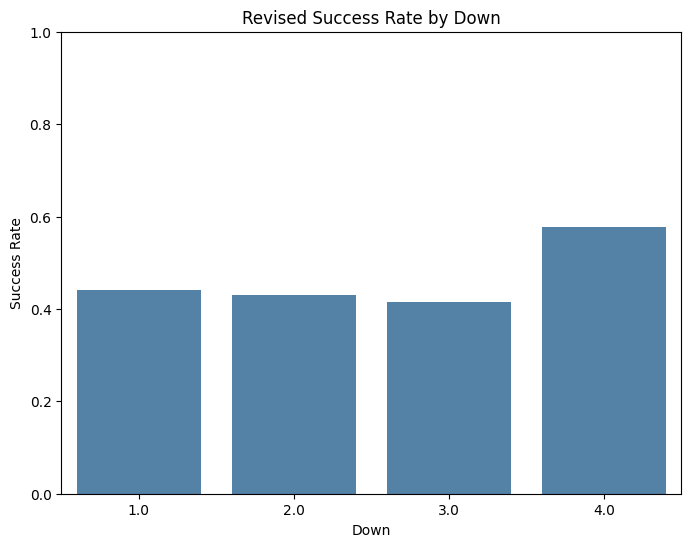

In [18]:
# calculate conversion percentage

# apply traditional benchmark thresholds based on the current down
recent_pbp = recent_pbp.with_columns(
    pl.when(pl.col('down') == 1.0).then(0.50)
    .when(pl.col('down') == 2.0).then(0.70)
    .when(pl.col('down') == 3.0).then(0.90)
    .when(pl.col('down') == 4.0).then(1.0)
    .otherwise(None)
    .alias('revised_threshold_pct')
).with_columns(
    # create binary success indicator
    pl.when(pl.col('conversion_pct_gained') >= pl.col('revised_threshold_pct'))
    .then(1)
    .otherwise(0)
    .alias('revised_success_benchmark')
)

# preview the engineered columns
print("--- Revised Success Preview ---")
display(recent_pbp.select([
    'down', 'ydstogo', 'yards_gained', 'conversion_pct_gained',
    'revised_threshold_pct', 'revised_success_benchmark'
]).head())

# save the aggregated data to a variable instead of computing it inside the display function
success_by_down = recent_pbp.group_by('down').agg(
    pl.col('revised_success_benchmark').mean().round(3).alias('revised_success_rate')
).drop_nulls('down').sort('down')

# display the aggregated table
print("\n--- Revised Success Rate by Down ---")
display(success_by_down)

# Calculate the standard deviation of 'revised_success_rate' for downs 1-3 only
std_dev_revised_success_rate = success_by_down.filter(pl.col('down').is_in([1.0, 2.0, 3.0]))['revised_success_rate'].std()
print(f"Standard Deviation of Revised Success Rate (Downs 1-3): {std_dev_revised_success_rate:.4f}")

# extract polars columns directly to lists to bypass pandas conversion
downs_list = success_by_down['down'].to_list()
rates_list = success_by_down['revised_success_rate'].to_list()

# build the bar chart
plt.figure(figsize=(8, 6))
sns.barplot(x=downs_list, y=rates_list, color='steelblue')
plt.title('Revised Success Rate by Down')
plt.xlabel('Down')
plt.ylabel('Success Rate')
plt.ylim(0, 1.0)
plt.show()

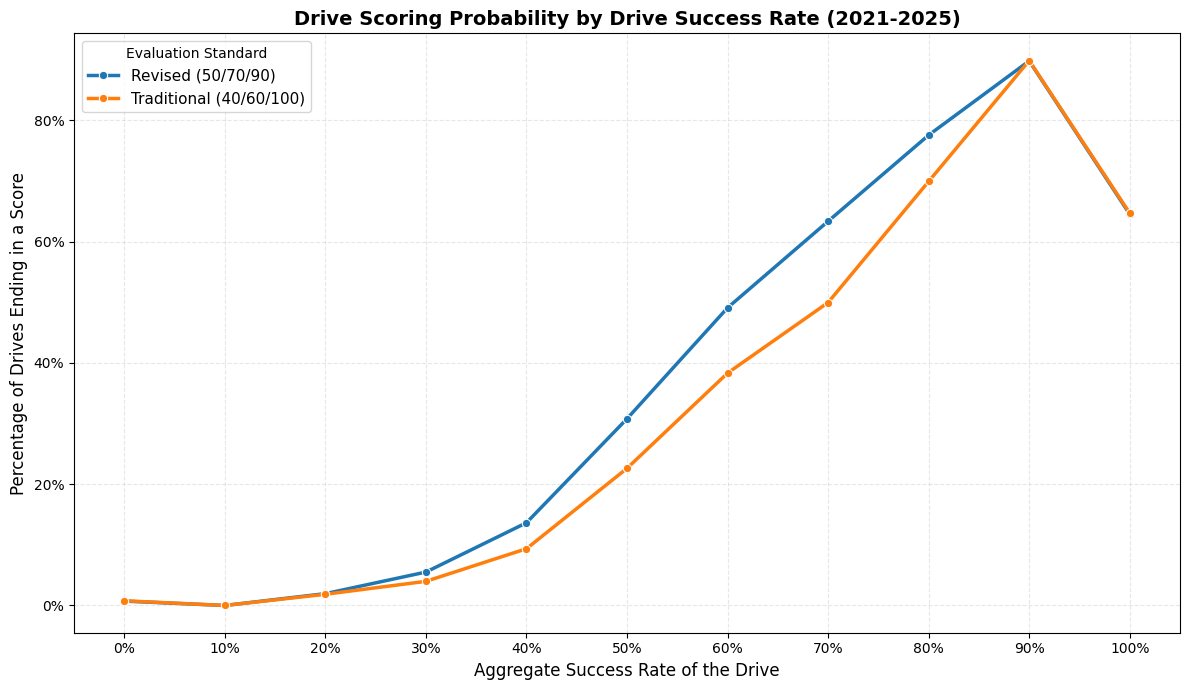

In [19]:
def calculate_scoring_by_drive_sr(pbp_data):
    # Ensure the base conversion percentage feature exists in the current scope
    if 'conversion_pct_gained' not in pbp_data.columns:
        pbp_data = pbp_data.with_columns(
            (pl.col('yards_gained') / pl.col('ydstogo')).alias('conversion_pct_gained')
        )

    # Filter for valid plays inside a definitive drive
    eda = pbp_data.filter(
        (pl.col('drive').is_not_null()) &
        (pl.col('fixed_drive_result').is_not_null()) &
        (pl.col('play_type').is_in(['pass', 'run']))
    )

    # Flag play-level success using both frameworks
    eda = eda.with_columns([
        # Traditional (40/60/100)
        pl.when((pl.col('down') == 1.0) & (pl.col('conversion_pct_gained') >= 0.4)).then(1)
          .when((pl.col('down') == 2.0) & (pl.col('conversion_pct_gained') >= 0.6)).then(1)
          .when((pl.col('down') == 3.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .when((pl.col('down') == 4.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .otherwise(0).alias('trad_sr_play'),

        # Revised (50/70/90/100)
        pl.when((pl.col('down') == 1.0) & (pl.col('conversion_pct_gained') >= 0.5)).then(1)
          .when((pl.col('down') == 2.0) & (pl.col('conversion_pct_gained') >= 0.7)).then(1)
          .when((pl.col('down') == 3.0) & (pl.col('conversion_pct_gained') >= 0.9)).then(1)
          .when((pl.col('down') == 4.0) & (pl.col('conversion_pct_gained') >= 1.0)).then(1)
          .otherwise(0).alias('rev_sr_play')
    ])

    # Aggregate to the drive level
    drive_df = eda.group_by(['game_id', 'drive']).agg([
        pl.col('trad_sr_play').mean().alias('drive_trad_sr'),
        pl.col('rev_sr_play').mean().alias('drive_rev_sr'),
        pl.col('fixed_drive_result').first().alias('drive_result')
    ])

    # Flag if the drive ended in a Score
    drive_df = drive_df.with_columns(
        pl.when(pl.col('drive_result').is_in(['Touchdown', 'Field Goal']))
        .then(1).otherwise(0).alias('scored')
    )

    # Bin success rates to the nearest 10% for smooth plotting
    drive_df = drive_df.with_columns([
        (pl.col('drive_trad_sr') * 10).round(0).cast(pl.Int32).alias('trad_bin'),
        (pl.col('drive_rev_sr') * 10).round(0).cast(pl.Int32).alias('rev_bin')
    ])

    # Group and calculate scoring probabilities for Traditional
    trad_grouped = drive_df.group_by('trad_bin').agg([
        pl.col('scored').mean().alias('Scoring Probability'),
        pl.col('scored').count().alias('Sample Size')
    ]).rename({'trad_bin': 'SR_Bin'})

    trad_grouped = trad_grouped.with_columns(pl.lit('Traditional (40/60/100)').alias('Metric Framework'))

    # Group and calculate scoring probabilities for Revised
    rev_grouped = drive_df.group_by('rev_bin').agg([
        pl.col('scored').mean().alias('Scoring Probability'),
        pl.col('scored').count().alias('Sample Size')
    ]).rename({'rev_bin': 'SR_Bin'})

    rev_grouped = rev_grouped.with_columns(pl.lit('Revised (50/70/90)').alias('Metric Framework'))

    # Combine frameworks, filter out tiny edge-case bins, and convert bin integers back to percentages
    plot_df = pl.concat([trad_grouped, rev_grouped]).filter(pl.col('Sample Size') >= 25)
    plot_df = plot_df.with_columns((pl.col('SR_Bin') / 10.0).alias('Drive Success Rate'))

    return plot_df.sort(['Metric Framework', 'Drive Success Rate']).to_pandas()

# Execute calculation using the master dataframe
sr_results_df = calculate_scoring_by_drive_sr(recent_pbp)

# Visualize the comparison
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=sr_results_df,
    x='Drive Success Rate',
    y='Scoring Probability',
    hue='Metric Framework',
    marker='o',
    linewidth=2.5,
    palette=['#1f77b4', '#ff7f0e']
)

# Format chart aesthetics
plt.title('Drive Scoring Probability by Drive Success Rate (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Aggregate Success Rate of the Drive', fontsize=12)
plt.ylabel('Percentage of Drives Ending in a Score', fontsize=12)
plt.gca().xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks([i/10.0 for i in range(0, 11)])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=11, title='Evaluation Standard')
plt.tight_layout()
plt.show()

In [20]:
# Calculate the standard deviation of 'revised_success_rate'
std_dev_revised_success_rate = success_by_down['revised_success_rate'].std()
print(f"Standard Deviation of Revised Success Rate: {std_dev_revised_success_rate:.4f}")

Standard Deviation of Revised Success Rate: 0.0756


In [21]:
# calculate alignment of revised success rate with positive epa plays

# Create a cross-tabulation to compare the two metrics
print("--- Cross-Tabulation: Revised vs. Positive EPA ---")
comparison_matrix = recent_pbp .group_by(['revised_success_benchmark', 'is_pos_epa']).len().sort(['revised_success_benchmark', 'is_pos_epa'])
display(comparison_matrix)

# Calculate the overall agreement rate
# How often does the traditional benchmark correctly identify a positive EPA play?
agreement_df = recent_pbp .with_columns(
    pl.when(pl.col('revised_success_benchmark') == pl.col('is_pos_epa'))
    .then(1)
    .otherwise(0)
    .alias('metrics_agree')
)

agreement_rate = agreement_df['metrics_agree'].mean()
print(f"\nOverall Agreement Rate: {agreement_rate:.2%}")

# Investigate the Disagreements (The "Inefficiencies")
# Let's look at plays that were a traditional "Success" but had NEGATIVE EPA
false_positives = recent_pbp .filter(
    (pl.col('revised_success_benchmark') == 1) & (pl.col('is_pos_epa') == 0)
)
print(f"\nTotal Revised 'Successes' that resulted in Negative EPA: {false_positives.height}")

--- Cross-Tabulation: Revised vs. Positive EPA ---


revised_success_benchmark,is_pos_epa,len
i32,i32,u32
0,0,68795
0,1,3342
1,0,2802
1,1,52567



Overall Agreement Rate: 95.18%

Total Revised 'Successes' that resulted in Negative EPA: 2802


In [22]:
# check other metrics for agreement rate beyond accuracy - revised metrics

# isolate ground truth and prediction columns dropping any nulls to ensure clean math
evaluation_metrics = recent_pbp .select([
    pl.col('is_pos_epa').alias('actual'),
    pl.col('revised_success_benchmark').alias('predicted')
]).drop_nulls()

# extract true labels and predictions to numpy arrays for scikit learn compatibility
y_true = evaluation_metrics['actual'].to_numpy()
y_pred = evaluation_metrics['predicted'].to_numpy()

# calculate confusion matrix
# scikit learn returns an array structured as true negatives false positives then false negatives true positives
conf_matrix = confusion_matrix(y_true, y_pred)

tn = conf_matrix[0, 0]
fp = conf_matrix[0, 1]
fn = conf_matrix[1, 0]
tp = conf_matrix[1, 1]

# calculate classification metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f_one_score = f1_score(y_true, y_pred)

# output the formatted results
print("--- Confusion Matrix ---")
print(f"True Positives (Correctly labeled Success): {tp}")
print(f"False Positives (Labeled Success but negative EPA): {fp}")
print(f"True Negatives (Correctly labeled Failure): {tn}")
print(f"False Negatives (Labeled Failure but positive EPA): {fn}")

print("\n--- Classification Metrics ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f_one_score:.4f}")

--- Confusion Matrix ---
True Positives (Correctly labeled Success): 52567
False Positives (Labeled Success but negative EPA): 2802
True Negatives (Correctly labeled Failure): 68795
False Negatives (Labeled Failure but positive EPA): 3342

--- Classification Metrics ---
Accuracy:  0.9518
Precision: 0.9494
Recall:    0.9402
F1 Score:  0.9448


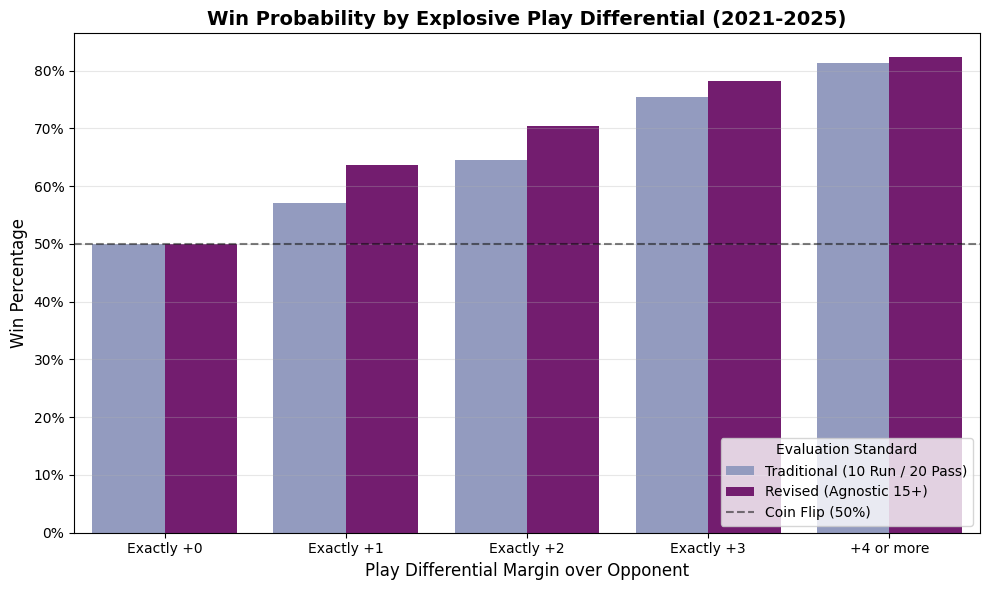

--- Predictive Framework Summary ---


,Differential Margin,Framework,Win Percentage
0,Exactly +0,Traditional (10 Run / 20 Pass),0.500000
1,Exactly +0,Revised (Agnostic 15+),0.500000
2,Exactly +1,Traditional (10 Run / 20 Pass),0.570064
3,Exactly +1,Revised (Agnostic 15+),0.636364
4,Exactly +2,Traditional (10 Run / 20 Pass),0.645985
5,Exactly +2,Revised (Agnostic 15+),0.703333
6,Exactly +3,Traditional (10 Run / 20 Pass),0.754717
7,Exactly +3,Revised (Agnostic 15+),0.781377
8,+4 or more,Traditional (10 Run / 20 Pass),0.814016
9,+4 or more,Revised (Agnostic 15+),0.823362


In [36]:
def evaluate_predictiveness_only(pbp_data):
    # flag plays using both the traditional and revised definitions
    metrics_df = pbp_data.with_columns([
        pl.when((pl.col('play_type') == 'run') & (pl.col('yards_gained') >= 10.0)).then(1)
          .when((pl.col('play_type') == 'pass') & (pl.col('yards_gained') >= 20.0)).then(1)
          .otherwise(0).alias('trad_explosive'),

        pl.when(pl.col('yards_gained') >= 15.0).then(1)
          .otherwise(0).alias('rev_explosive')
    ])

    # sum explosive plays per team per game for both frameworks
    team_game_explosive = metrics_df.group_by(['game_id', 'posteam']).agg([
        pl.col('trad_explosive').sum().alias('trad_plays'),
        pl.col('rev_explosive').sum().alias('rev_plays')
    ]).rename({"posteam": "team"})

    # extract unique games and final scores directly from play-by-play
    games = pbp_data.group_by(['game_id', 'home_team', 'away_team']).agg([
        pl.col('home_score').max().alias('home_score'),
        pl.col('away_score').max().alias('away_score')
    ])

    home_games = games.select([
        pl.col('game_id'), pl.col('home_team').alias('team'),
        (pl.col('home_score') > pl.col('away_score')).cast(pl.Int32).alias('win'),
        (pl.col('home_score') == pl.col('away_score')).cast(pl.Int32).alias('tie')
    ])

    away_games = games.select([
        pl.col('game_id'), pl.col('away_team').alias('team'),
        (pl.col('away_score') > pl.col('home_score')).cast(pl.Int32).alias('win'),
        (pl.col('away_score') == pl.col('home_score')).cast(pl.Int32).alias('tie')
    ])

    game_outcomes = pl.concat([home_games, away_games]).filter(pl.col('tie') == 0)

    # join outcomes with explosive play counts
    merged = game_outcomes.join(team_game_explosive, on=['game_id', 'team'], how='left').fill_null(0)

    # isolate opponents to calculate differentials
    opponents = merged.select([
        pl.col('game_id'),
        pl.col('team').alias('opp_team'),
        pl.col('trad_plays').alias('opp_trad_plays'),
        pl.col('rev_plays').alias('opp_rev_plays')
    ])

    matchups = merged.join(opponents, on='game_id').filter(pl.col('team') != pl.col('opp_team'))

    # calculate the net differential for both frameworks
    matchups = matchups.with_columns([
        (pl.col('trad_plays') - pl.col('opp_trad_plays')).alias('trad_diff'),
        (pl.col('rev_plays') - pl.col('opp_rev_plays')).alias('rev_diff')
    ])

    results = []

    # loop through 0, 1, 2, 3, and 4
    # apply specific conditional logic to make 4 the catch-all bucket
    for diff in [0, 1, 2, 3, 4]:
        if diff == 4:
            # catch-all bucket for 4 or more
            label = "+4 or more"
            trad_filter = (pl.col('trad_diff') >= 4)
            rev_filter = (pl.col('rev_diff') >= 4)
        else:
            # strict equality for exactly 0, 1, 2, and 3
            label = f"Exactly +{diff}"
            trad_filter = (pl.col('trad_diff') == diff)
            rev_filter = (pl.col('rev_diff') == diff)

        # evaluate traditional framework
        trad_won = matchups.filter(trad_filter)
        trad_win_pct = trad_won['win'].mean() if trad_won.height > 0 else 0

        results.append({
            'Differential Margin': label,
            'Framework': 'Traditional (10 Run / 20 Pass)',
            'Win Percentage': trad_win_pct
        })

        # evaluate revised framework
        rev_won = matchups.filter(rev_filter)
        rev_win_pct = rev_won['win'].mean() if rev_won.height > 0 else 0

        results.append({
            'Differential Margin': label,
            'Framework': 'Revised (Agnostic 15+)',
            'Win Percentage': rev_win_pct
        })

    return pl.DataFrame(results).to_pandas()

# execute the calculation
predictiveness_df = evaluate_predictiveness_only(recent_pbp)

# visualize the focused comparison
plt.figure(figsize=(10, 6))
sns.set_palette(['#8c96c6', '#810f7c'])

ax = sns.barplot(
    data=predictiveness_df,
    x='Differential Margin',
    y='Win Percentage',
    hue='Framework'
)

plt.title('Win Probability by Explosive Play Differential (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Play Differential Margin over Opponent', fontsize=12)
plt.ylabel('Win Percentage', fontsize=12)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(True, axis='y', alpha=0.3)

# add a reference line for a coin flip
plt.axhline(y=0.50, color='black', linestyle='--', alpha=0.5, label='Coin Flip (50%)')

plt.legend(title='Evaluation Standard', loc='lower right')
plt.tight_layout()
plt.show()

print("--- Predictive Framework Summary ---")
display(predictiveness_df)

In [27]:
import polars as pl
import statsmodels.api as sm

def check_threshold_sensitivity(pbp_data):
    # 1. calculate season points internally to avoid scope errors
    games = pbp_data.group_by(['season', 'game_id', 'home_team', 'away_team']).agg([
        pl.col('home_score').max().alias('home_final'),
        pl.col('away_score').max().alias('away_final')
    ])

    home_pts = games.select([
        'season', pl.col('home_team').alias('team'),
        pl.col('home_final').alias('pts_for')
    ])
    away_pts = games.select([
        'season', pl.col('away_team').alias('team'),
        pl.col('away_final').alias('pts_for')
    ])

    season_points_df = pl.concat([home_pts, away_pts]).group_by(['season', 'team']).agg([
        pl.col('pts_for').mean().alias('ppg_for')
    ])

    # 2. engineer flags for both 15 and 16 yard thresholds
    sensitivity_df = pbp_data.with_columns([
        pl.when(pl.col('yards_gained') >= 15.0).then(1).otherwise(0).alias('exp_15'),
        pl.when(pl.col('yards_gained') >= 16.0).then(1).otherwise(0).alias('exp_16')
    ])

    # 3. aggregate to season level counts per game
    agg_metrics = sensitivity_df.group_by(['season', 'posteam']).agg([
        (pl.col('exp_15').sum() / pl.col('game_id').n_unique()).alias('exp_15_pg'),
        (pl.col('exp_16').sum() / pl.col('game_id').n_unique()).alias('exp_16_pg')
    ]).rename({"posteam": "team"})

    # 4. join with the internally generated scoring data
    master_comp = season_points_df.join(agg_metrics, on=['season', 'team']).to_pandas()

    # 5. test 15 yard model
    x_15 = sm.add_constant(master_comp['exp_15_pg'])
    model_15 = sm.OLS(master_comp['ppg_for'], x_15).fit()

    # 6. test 16 yard model
    x_16 = sm.add_constant(master_comp['exp_16_pg'])
    model_16 = sm.OLS(master_comp['ppg_for'], x_16).fit()

    print("--- Threshold Sensitivity Results ---")
    print(f"15 Yard R-Squared: {model_15.rsquared:.4f} | AIC: {model_15.aic:.2f}")
    print(f"16 Yard R-Squared: {model_16.rsquared:.4f} | AIC: {model_16.aic:.2f}")

# execute the sensitivity check using only the master pbp dataframe
check_threshold_sensitivity(recent_pbp)

--- Threshold Sensitivity Results ---
15 Yard R-Squared: 0.4420 | AIC: 824.92
16 Yard R-Squared: 0.4192 | AIC: 831.35
